In [1]:
pip install -q nltk gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
conda install  pandas matplotlib seaborn scikit-learn nltk -c conda-forge

Solving environment: ...working... done

## Package Plan ##

  environment location: D:\miniconda\envs\myenv

  added / updated specs:
    - matplotlib
    - nltk
    - pandas
    - scikit-learn
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _libavif_api-1.4.1         |       h57928b3_0          10 KB  conda-forge
    aom-3.9.1                  |       he0c23c2_0         1.9 MB  conda-forge
    brotli-1.2.0               |       h2d644bc_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hfd05255_1          22 KB  conda-forge
    ca-certificates-2025.1.31  |       h56e8100_0         155 KB  conda-forge
    cairo-1.18.4               |       he9e932c_0         637 KB  defaults
    click-8.1.3                |  py310h5588dad_1         149 KB  conda-forge
    colorama-0.4.6             |     pyhd8ed1ab_1          26 KB  conda-forge
    contourpy-1.3.1     



==> WARNING: A newer version of conda exists. <==
  current version: 4.7.12
  latest version: 26.3.2

Please update conda by running

    $ conda update -n base conda




In [5]:
# 1. 首先尝试更新 conda 自身
conda update -n base -c defaults conda

# 2. 如果第一步成功，建议再次运行以确保达到最新版
conda update conda

SyntaxError: invalid syntax (1668521100.py, line 2)

In [6]:
# 1. 首先尝试更新 conda 自身
conda update -n base -c defaults conda


SyntaxError: invalid syntax (1243394109.py, line 2)

In [7]:
conda install -n base conda=26.3.2


Solving environment: ...working... failed with initial frozen solve. Retrying with flexible solve.
Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... failed with initial frozen solve. Retrying with flexible solve.
Solving environment: ...working... 
Found conflicts! Looking for incompatible packages.
This can take several minutes.  Press CTRL-C to abort.
failed

Note: you may need to restart the kernel to use updated packages.



Examining wincertstore:  11%|█         | 78/706 [00:00<00:00, 11813.66it/s]

Comparing specs that have this dependency:   0%|          | 0/2 [00:00<?, ?it/s]


Finding conflict paths:   0%|          | 0/1 [00:00<?, ?it/s]


Finding shortest conflict path for wincertstore[version='>=0.2']:   0%|          | 0/1 [00:00<?, ?it/s]


                                                                                                       

Comparing specs that have this dependency:  50%|█████     | 1/2 [00:00<00:00,  7.57it/s]


Finding conflict paths:   0%|          | 0/1 [00:00<?, ?it/s]


Finding shortest conflict path for wincertstore[version='>=0.2']:   0%|          | 0/1 [00:00<?, ?it/s]


                                                                                                       

Comparing specs that have this dependency: 100%|██████████| 2/2 [00:00<00:00,  3.54it/s]

                                                                                        
Examining python:  

In [8]:
import re, time, warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

warnings.filterwarnings('ignore')



import nltk

nltk.download('stopwords', quiet=True)

nltk.download('wordnet',   quiet=True)

nltk.download('punkt',     quiet=True)

from nltk.corpus import stopwords

from nltk.stem  import WordNetLemmatizer

from nltk.tokenize import word_tokenize



from sklearn.model_selection   import train_test_split

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.metrics           import accuracy_score, classification_report, confusion_matrix

from sklearn.pipeline          import Pipeline



# 10 Classifiers

from sklearn.linear_model     import LogisticRegression, SGDClassifier

from sklearn.naive_bayes      import MultinomialNB, BernoulliNB

from sklearn.svm              import LinearSVC

from sklearn.tree             import DecisionTreeClassifier

from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier

from sklearn.neighbors        import KNeighborsClassifier

from sklearn.linear_model     import PassiveAggressiveClassifier



print('All imports successful ✓')

All imports successful ✓


In [10]:
df = pd.read_csv('D:\IMDB Dataset.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head(3)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [11]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text):
    # 1. lowercase
    text = text.lower()
    # 2. remove HTML tags (IMDB reviews contain <br /> etc.)
    text = re.sub(r'<.*?>', ' ', text)
    # 3. remove punctuation & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. tokenize
    tokens = text.split()
    # 5. remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

print('Preprocessing 50k reviews — takes ~1 min...')
df['clean'] = df['review'].apply(preprocess)

# Encode label: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Done!')
print('\nSample:')
print('Original:', df['review'].iloc[0][:120])
print('Cleaned :', df['clean'].iloc[0][:120])

Preprocessing 50k reviews — takes ~1 min...
Done!

Sample:
Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
Cleaned : one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinchi


In [12]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 40,000  |  Test: 10,000


In [13]:
# Bag of Words
bow = CountVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

# TF-IDF
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'BoW   matrix: {X_train_bow.shape}')
print(f'TF-IDF matrix: {X_train_tfidf.shape}')

BoW   matrix: (40000, 30000)
TF-IDF matrix: (40000, 30000)


In [14]:
# We use TF-IDF for most models (better than BoW in practice)
# MultinomialNB requires non-negative features → BoW is safer there

classifiers = [
    ('Logistic Regression',       LogisticRegression(max_iter=1000, C=1.0),       'tfidf'),
    ('LinearSVC',                 LinearSVC(max_iter=2000),                        'tfidf'),
    ('SGD Classifier',            SGDClassifier(loss='hinge', max_iter=100),       'tfidf'),
    ('Passive Aggressive',        PassiveAggressiveClassifier(max_iter=100),       'tfidf'),
    ('Multinomial Naive Bayes',   MultinomialNB(alpha=0.1),                        'bow'),
    ('Bernoulli Naive Bayes',     BernoulliNB(alpha=0.1),                          'bow'),
    ('Decision Tree',             DecisionTreeClassifier(max_depth=20),            'tfidf'),
    ('Random Forest',             RandomForestClassifier(n_estimators=100, n_jobs=-1), 'tfidf'),
    ('Gradient Boosting',         GradientBoostingClassifier(n_estimators=100),    'tfidf'),
    ('K-Nearest Neighbors',       KNeighborsClassifier(n_neighbors=5),             'tfidf'),
]

results = []

for name, model, feat in classifiers:
    Xtr = X_train_tfidf if feat == 'tfidf' else X_train_bow
    Xte = X_test_tfidf  if feat == 'tfidf' else X_test_bow

    t0 = time.time()
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    elapsed = time.time() - t0

    acc  = accuracy_score(y_test, preds)
    rep  = classification_report(y_test, preds, output_dict=True)
    results.append({
        'Model':     name,
        'Features':  feat.upper(),
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(rep['weighted avg']['precision'] * 100, 2),
        'Recall':    round(rep['weighted avg']['recall']    * 100, 2),
        'F1-Score':  round(rep['weighted avg']['f1-score']  * 100, 2),
        'Time(s)':   round(elapsed, 1),
        '_preds':    preds,   # keep for confusion matrix
        '_model':    model,
    })
    print(f'{name:<30}  Acc={acc*100:.2f}%  ({elapsed:.1f}s)')

Logistic Regression             Acc=89.90%  (0.6s)
LinearSVC                       Acc=89.95%  (1.1s)
SGD Classifier                  Acc=89.92%  (0.2s)
Passive Aggressive              Acc=88.36%  (0.4s)
Multinomial Naive Bayes         Acc=87.07%  (0.0s)
Bernoulli Naive Bayes           Acc=87.40%  (0.1s)
Decision Tree                   Acc=74.82%  (24.2s)
Random Forest                   Acc=86.25%  (11.8s)
Gradient Boosting               Acc=81.44%  (159.5s)
K-Nearest Neighbors             Acc=76.29%  (17.4s)


In [15]:
cols = ['Model','Features','Accuracy','Precision','Recall','F1-Score','Time(s)']
df_results = pd.DataFrame(results)[cols].sort_values('Accuracy', ascending=False)
df_results = df_results.reset_index(drop=True)
df_results.index += 1   # rank starts at 1

# Highlight best / worst
best  = df_results.iloc[0]['Model']
worst = df_results.iloc[-1]['Model']
print(f'Best  model → {best}')
print(f'Worst model → {worst}\n')

df_results.style.background_gradient(subset=['Accuracy'], cmap='RdYlGn')

Best  model → LinearSVC
Worst model → Decision Tree



,Model,Features,Accuracy,Precision,Recall,F1-Score,Time(s)
1,LinearSVC,TFIDF,89.950000,89.960000,89.950000,89.950000,1.100000
2,SGD Classifier,TFIDF,89.920000,89.940000,89.920000,89.920000,0.200000
3,Logistic Regression,TFIDF,89.900000,89.910000,89.900000,89.900000,0.600000
4,Passive Aggressive,TFIDF,88.360000,88.360000,88.360000,88.360000,0.400000
5,Bernoulli Naive Bayes,BOW,87.400000,87.440000,87.400000,87.400000,0.100000
6,Multinomial Naive Bayes,BOW,87.070000,87.070000,87.070000,87.070000,0.000000
7,Random Forest,TFIDF,86.250000,86.270000,86.250000,86.250000,11.800000
8,Gradient Boosting,TFIDF,81.440000,81.800000,81.440000,81.390000,159.500000
9,K-Nearest Neighbors,TFIDF,76.290000,76.940000,76.290000,76.150000,17.400000
10,Decision Tree,TFIDF,74.820000,75.500000,74.820000,74.650000,24.200000


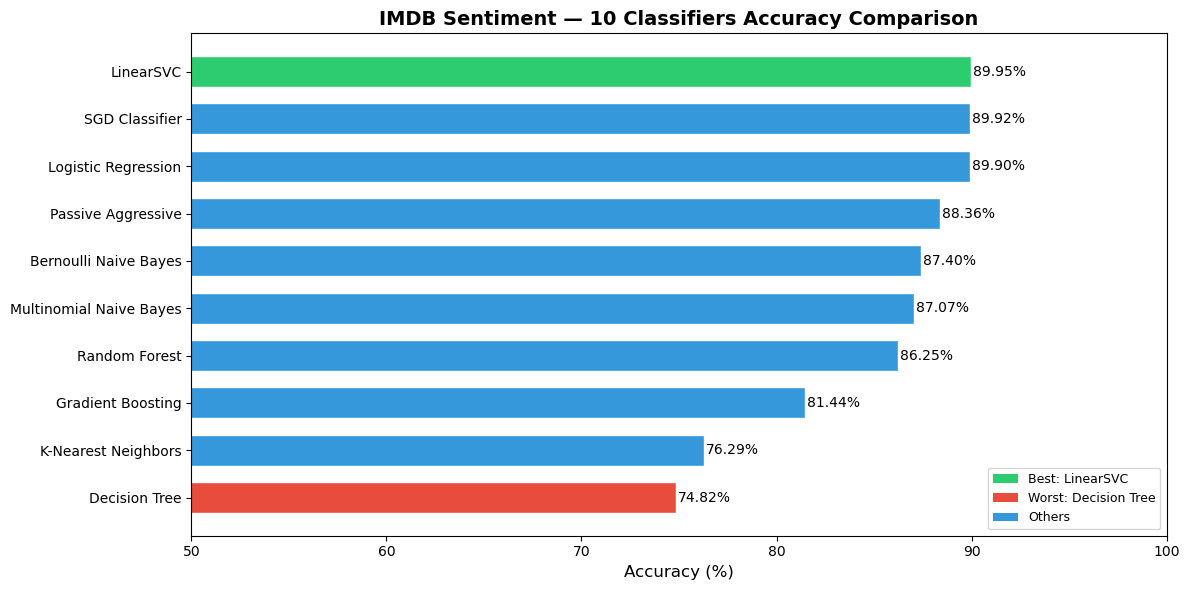

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if m == best else '#e74c3c' if m == worst else '#3498db'
          for m in df_results['Model']]

bars = ax.barh(df_results['Model'][::-1], df_results['Accuracy'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

for bar, val in zip(bars, df_results['Accuracy'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('IMDB Sentiment — 10 Classifiers Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(50, 100)

# Legend
from matplotlib.patches import Patch
legend = [Patch(facecolor='#2ecc71', label=f'Best: {best}'),
          Patch(facecolor='#e74c3c', label=f'Worst: {worst}'),
          Patch(facecolor='#3498db', label='Others')]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

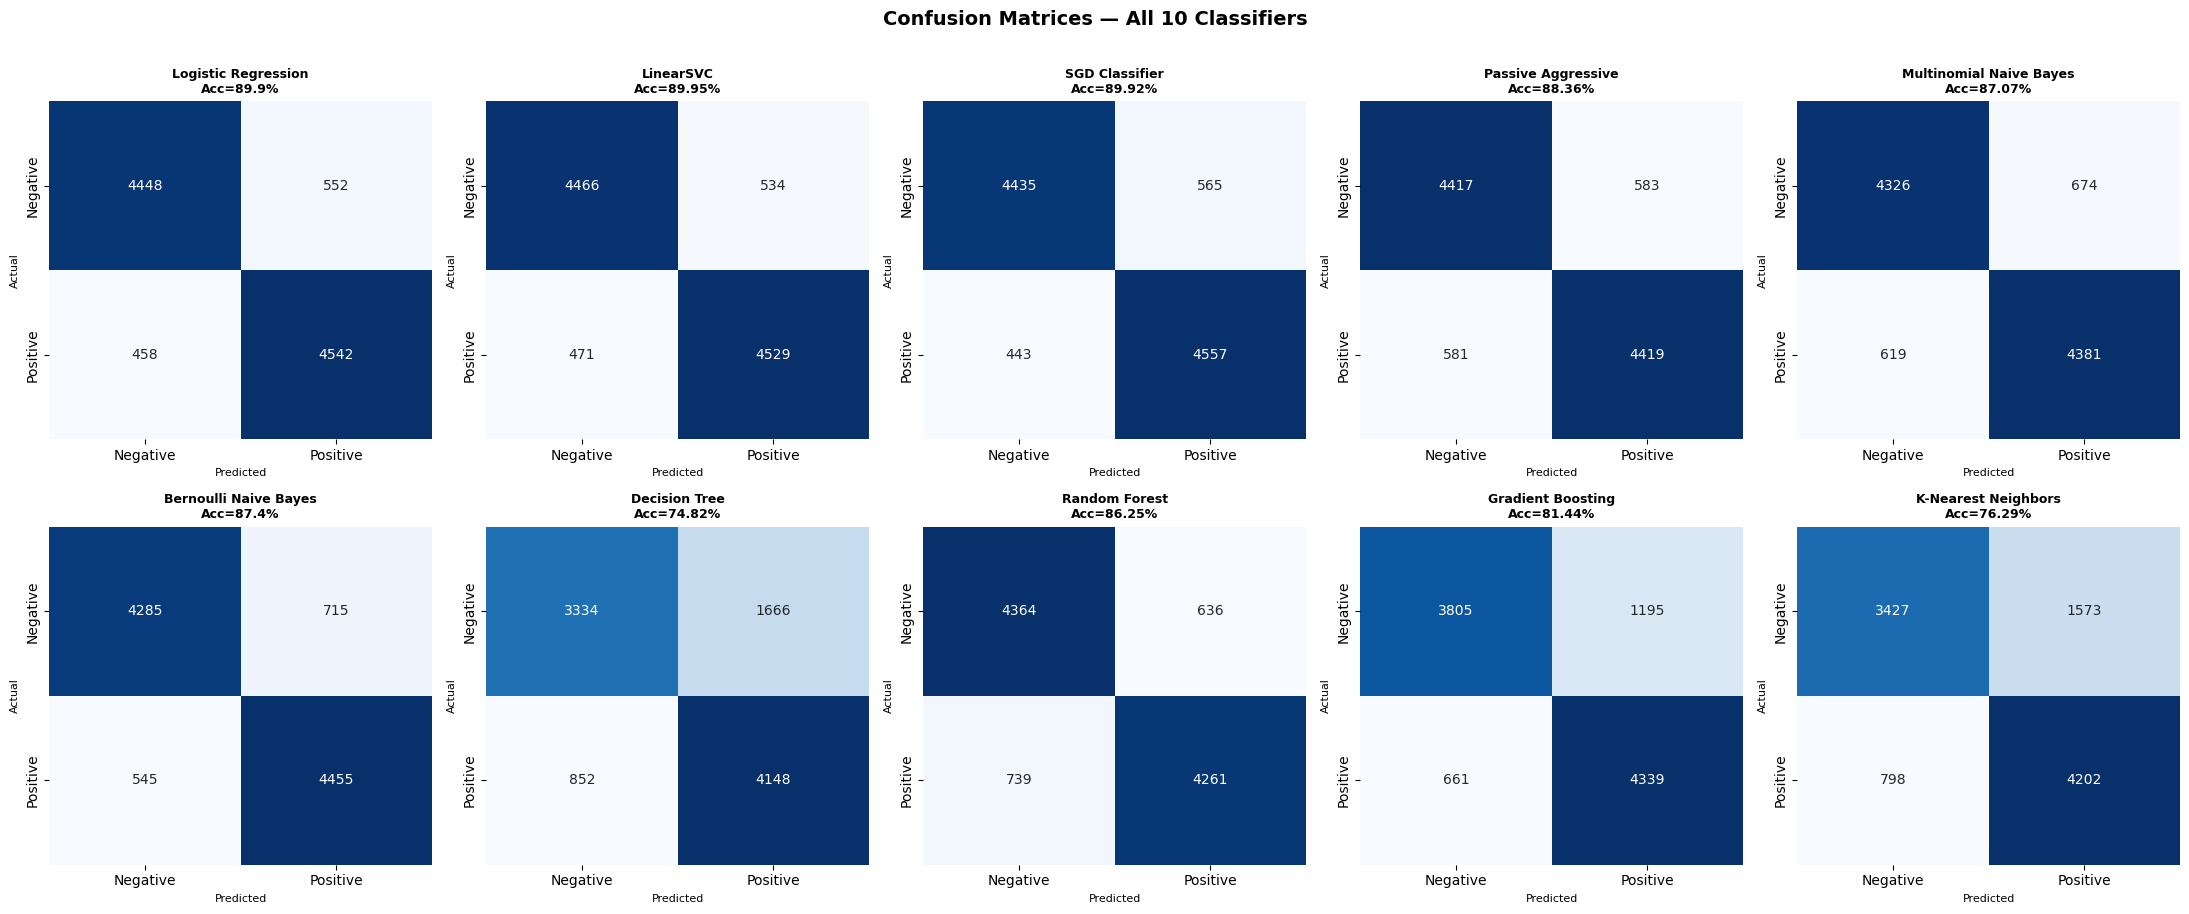

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
labels = ['Negative', 'Positive']

for i, row in enumerate(results):
    cm = confusion_matrix(y_test, row['_preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    acc = row['Accuracy']
    axes[i].set_title(f"{row['Model']}\nAcc={acc}%", fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('Actual',    fontsize=8)

plt.suptitle('Confusion Matrices — All 10 Classifiers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

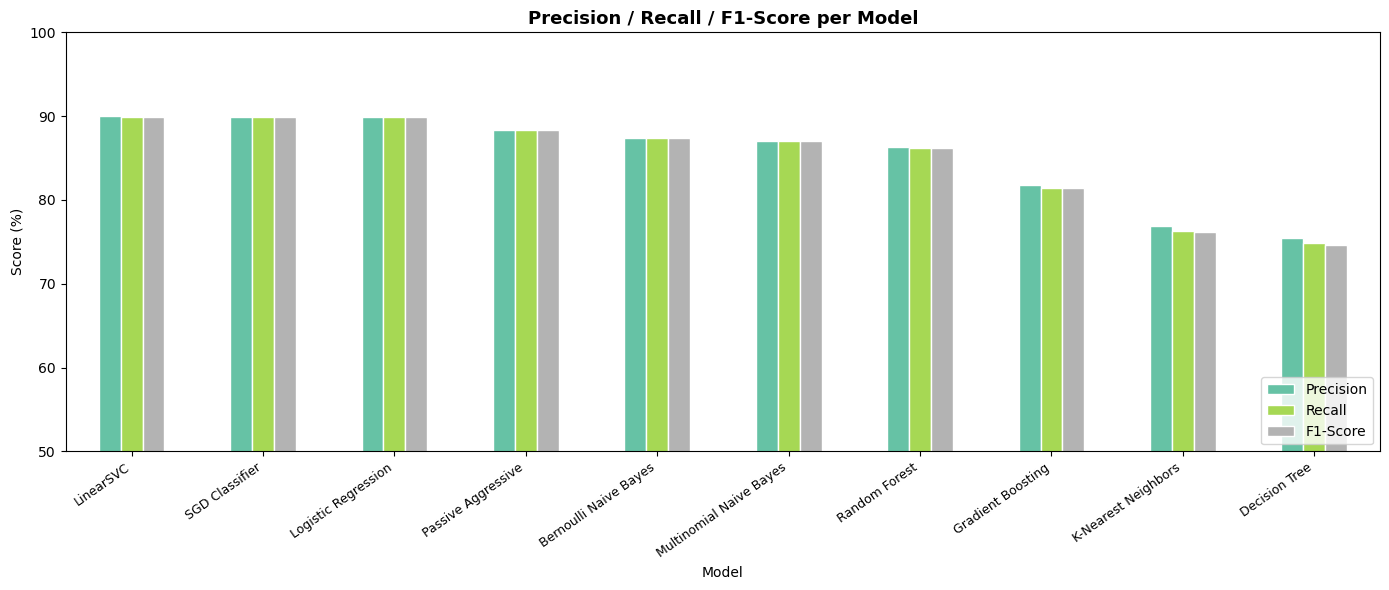

In [18]:
df_plot = df_results.set_index('Model')[['Precision','Recall','F1-Score']]
df_plot.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')

plt.title('Precision / Recall / F1-Score per Model', fontsize=13, fontweight='bold')
plt.ylabel('Score (%)')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylim(50, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# We train a Word2Vec model on the training reviews,
# then represent each review as the mean of its word vectors.
# Finally we train Logistic Regression on top → compare with TF-IDF LR.

from gensim.models import Word2Vec

# Tokenize for W2V (list of lists)
train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

print('Training Word2Vec (this takes ~1 min)...')
w2v = Word2Vec(
    sentences  = train_tokens,
    vector_size= 100,
    window     = 5,
    min_count  = 3,
    workers    = 4,
    epochs     = 5,
    sg         = 0      # 0 = CBOW, 1 = Skip-gram
)

def doc_vector(tokens, model):
    """Average word vectors for a document."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_train_w2v = np.array([doc_vector(t, w2v) for t in train_tokens])
X_test_w2v  = np.array([doc_vector(t, w2v) for t in test_tokens])

lr_w2v = LogisticRegression(max_iter=1000, C=1.0)
lr_w2v.fit(X_train_w2v, y_train)
preds_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v   = accuracy_score(y_test, preds_w2v)

# Compare with TF-IDF LR
tfidf_acc = next(r['Accuracy'] for r in results if r['Model'] == 'Logistic Regression')

print(f'\nLogistic Regression + TF-IDF  : {tfidf_acc}%')
print(f'Logistic Regression + Word2Vec: {acc_w2v*100:.2f}%')
print('\nNote: W2V on small corpus often underperforms TF-IDF.')
print('Pre-trained GloVe / fastText embeddings would close this gap.')

Training Word2Vec (this takes ~1 min)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Logistic Regression + TF-IDF  : 89.9%
Logistic Regression + Word2Vec: 86.11%

Note: W2V on small corpus often underperforms TF-IDF.
Pre-trained GloVe / fastText embeddings would close this gap.


In [20]:
for word in ['good', 'bad', 'film', 'terrible']:
    try:
        similar = w2v.wv.most_similar(word, topn=5)
        words   = [w for w, _ in similar]
        print(f'{word:10} → {words}')
    except KeyError:
        print(f'{word:10} → not in vocabulary')

good       → ['decent', 'great', 'bad', 'fine', 'nice']
bad        → ['terrible', 'awful', 'horrible', 'good', 'lousy']
film       → ['movie', 'cinema', 'flick', 'documentary', 'picture']
terrible   → ['horrible', 'awful', 'dreadful', 'lousy', 'horrid']


In [21]:
print('='*60)
print('           FINAL RESULTS SUMMARY')
print('='*60)
print(df_results[['Model','Accuracy','F1-Score','Time(s)']].to_string(index=True))
print('='*60)
print(f'Best  model : {best}  ({df_results.iloc[0]["Accuracy"]}%)')
print(f'Worst model : {worst} ({df_results.iloc[-1]["Accuracy"]}%)')
print('='*60)

           FINAL RESULTS SUMMARY
                      Model  Accuracy  F1-Score  Time(s)
1                 LinearSVC     89.95     89.95      1.1
2            SGD Classifier     89.92     89.92      0.2
3       Logistic Regression     89.90     89.90      0.6
4        Passive Aggressive     88.36     88.36      0.4
5     Bernoulli Naive Bayes     87.40     87.40      0.1
6   Multinomial Naive Bayes     87.07     87.07      0.0
7             Random Forest     86.25     86.25     11.8
8         Gradient Boosting     81.44     81.39    159.5
9       K-Nearest Neighbors     76.29     76.15     17.4
10            Decision Tree     74.82     74.65     24.2
Best  model : LinearSVC  (89.95%)
Worst model : Decision Tree (74.82%)
